# Neg-t-SNE embedding spectrum (MNIST)

## Mục tiêu

Tái hiện **Fig. 1 (a–e)** trong *From t-SNE to UMAP with contrastive learning* (Damrich et al., ICLR 2023): chạy **Neg-t-SNE** trên MNIST và thay $\bar{Z}$ theo cấp số nhân từ $10^4$ đến $10^{12}$.

Khi $\bar{Z}$ tăng, embedding dịch từ kiểu **t-SNE** (cục bộ) sang **UMAP** (toàn cục hơn). Paper dùng **early exaggeration** với $\bar{Z} \approx n^2/m$ trước khi sweep $\bar{Z}$.

Implementation: [`NegTSNE`](../models/neg_tsne.py) bọc **`cne.CNE`** (package [contrastive-ne](https://github.com/berenslab/contrastive-ne)). Không dùng `external/`.

## Cài đặt

```powershell
uv sync
```

Package pip: **contrastive-ne** → trong code: `from cne import CNE`. kNN: **scikit-learn** ([`docs/INSTALL.md`](../../docs/INSTALL.md)).

`NegTSNE` bọc **`cne.CNE`** và truyền đồ thị kNN sklearn vào `CNE.fit_transform(..., graph=...)`.

## Dữ liệu

`code/data/raw/mnist.hdf5` (70 000 × 784).

In [4]:
import sys
from pathlib import Path

def _lab_root() -> Path:
    start = Path.cwd().resolve()
    for d in [start, *start.parents]:
        if (d / "pyproject.toml").is_file() and (d / "code" / "data" / "load_data.py").is_file():
            return d
    raise RuntimeError("cd to lab-2 (folder with pyproject.toml), then re-run.")

lab_root = _lab_root()
sys.path.insert(0, str(lab_root / "code"))
print("Lab root:", lab_root)

import numpy as np
import matplotlib.pyplot as plt

from models.neg_tsne import fit_neg_tsne_spectrum, z_bars_full, z_ee
from utils.viz import plot_embedding_spectrum

try:
    import torch
    print("CUDA:", torch.cuda.is_available())
except ImportError:
    print("PyTorch not installed")

Lab root: D:\hcmus\semester-6\introduction-to-machine-learning\csc14005-introduction-to-machine-learning\lab-2
CUDA: False


## 1. Load MNIST

In [5]:
import h5py

data_path = lab_root / "code" / "data" / "raw" / "mnist.hdf5"
if not data_path.is_file():
    raise FileNotFoundError(f"Place MNIST at {data_path}")

with h5py.File(data_path, "r") as hf:
    X_train = np.asarray(hf["items/1/items/1/rcargs/items/0"], dtype=np.float32)
    y_train = np.asarray(
        hf["items/1/items/1/rcargs/items/1/items/0/items/1/rcargs/items/0"],
        dtype=np.int64,
    )
    X_test = np.asarray(hf["items/0/items/1/rcargs/items/0"], dtype=np.float32)
    y_test = np.asarray(
        hf["items/0/items/1/rcargs/items/1/items/0/items/1/rcargs/items/0"],
        dtype=np.int64,
    )
    X = np.vstack([X_train, X_test]) / 255.0
    y = np.concatenate([y_train, y_test])

n_samples = X.shape[0]
print(f"MNIST: X={X.shape}, y={y.shape}")

MNIST: X=(70000, 784), y=(70000,)


## 2. Cấu hình thực nghiệm

| Tham số | Full (paper) | `QUICK_TEST=True` (mặc định) |
|---------|----------------|------------------------------|
| Samples | 70 000 | 5 000 subset |
| `n_epochs` | 500 | 50 |
| $\bar{Z}$ | `logspace(4, 12, 9)` | `logspace(4, 8, 5)` |
| `batch_size` | 1024 | 512 |

Tắt `QUICK_TEST` khi có GPU để chạy full spectrum.

In [6]:
SEED = 0
K = 15
NEG_SAMPLES = 5
N_EPOCHS = 500
BATCH_SIZE = 1024
DEVICE = "auto"
DATA_ON_GPU = False

QUICK_TEST = True
Z_BARS = z_bars_full()

if QUICK_TEST:
    rng = np.random.default_rng(SEED)
    idx = rng.choice(n_samples, size=min(5000, n_samples), replace=False)
    X = X[idx]
    y = y[idx]
    n_samples = len(X)
    N_EPOCHS = 50
    BATCH_SIZE = 512
    Z_BARS = np.logspace(4, 8, 5)
    print("QUICK_TEST: subset + reduced epochs / Z_bar values")

print(f"n={n_samples:,}, Z_EE={z_ee(n_samples, NEG_SAMPLES):.3e}")
print("Z_bar:", ", ".join(f"{z:.0e}" for z in Z_BARS))

QUICK_TEST: subset + reduced epochs / Z_bar values
n=5,000, Z_EE=5.000e+06
Z_bar: 1e+04, 1e+05, 1e+06, 1e+07, 1e+08


## 3. Chạy spectrum (EE + sweep $\bar{Z}$)

In [7]:
embeddings, runtimes_min, init_ee = fit_neg_tsne_spectrum(
    X,
    Z_BARS,
    k=K,
    negative_samples=NEG_SAMPLES,
    batch_size=BATCH_SIZE,
    n_epochs=N_EPOCHS,
    seed=SEED,
    device=DEVICE,
    data_on_gpu=DATA_ON_GPU,
    verbose=True,
)

print("\nRuntimes (min), main phase:")
for z, t in sorted(runtimes_min.items()):
    print(f"  Z_bar={z:.3e}: {t:.1f}")

Building kNN graph (k=15) with sklearn...
n=5,000 | EE: Z_bar=5.000e+06, epochs=16


Finished epoch 0/16, loss 1233.098
Finished epoch 3/16, loss 780.885
Finished epoch 6/16, loss 741.132
Finished epoch 9/16, loss 718.447
Finished epoch 12/16, loss 702.121
Finished epoch 15/16, loss 688.876


EE finished in 0.1 min

=== Z_bar = 1.000e+04 (34 epochs) ===


Finished epoch 0/34, loss 3545.040
Finished epoch 6/34, loss 1364.606
Finished epoch 12/34, loss 1142.097
Finished epoch 18/34, loss 1040.849
Finished epoch 24/34, loss 990.579
Finished epoch 30/34, loss 969.459


Done in 0.1 min

=== Z_bar = 1.000e+05 (34 epochs) ===


...

Done in 0.2 min

=== Z_bar = 1.000e+07 (34 epochs) ===


Finished epoch 0/34, loss 990.085
Finished epoch 6/34, loss 940.980
Finished epoch 12/34, loss 897.648
Finished epoch 18/34, loss 867.092
Finished epoch 24/34, loss 846.449
Finished epoch 30/34, loss 832.768


Done in 0.2 min

=== Z_bar = 1.000e+08 (34 epochs) ===


Finished epoch 0/34, loss 2021.540
Finished epoch 6/34, loss 1855.593
Finished epoch 12/34, loss 1758.689
Finished epoch 18/34, loss 1686.349
Finished epoch 24/34, loss 1655.409
Finished epoch 30/34, loss 1643.804


Done in 0.2 min

Runtimes (min), main phase:
  Z_bar=1.000e+04: 0.1
  Z_bar=1.000e+05: 0.1
  Z_bar=1.000e+06: 0.2
  Z_bar=1.000e+07: 0.2
  Z_bar=1.000e+08: 0.2


## 4. Trực quan hóa

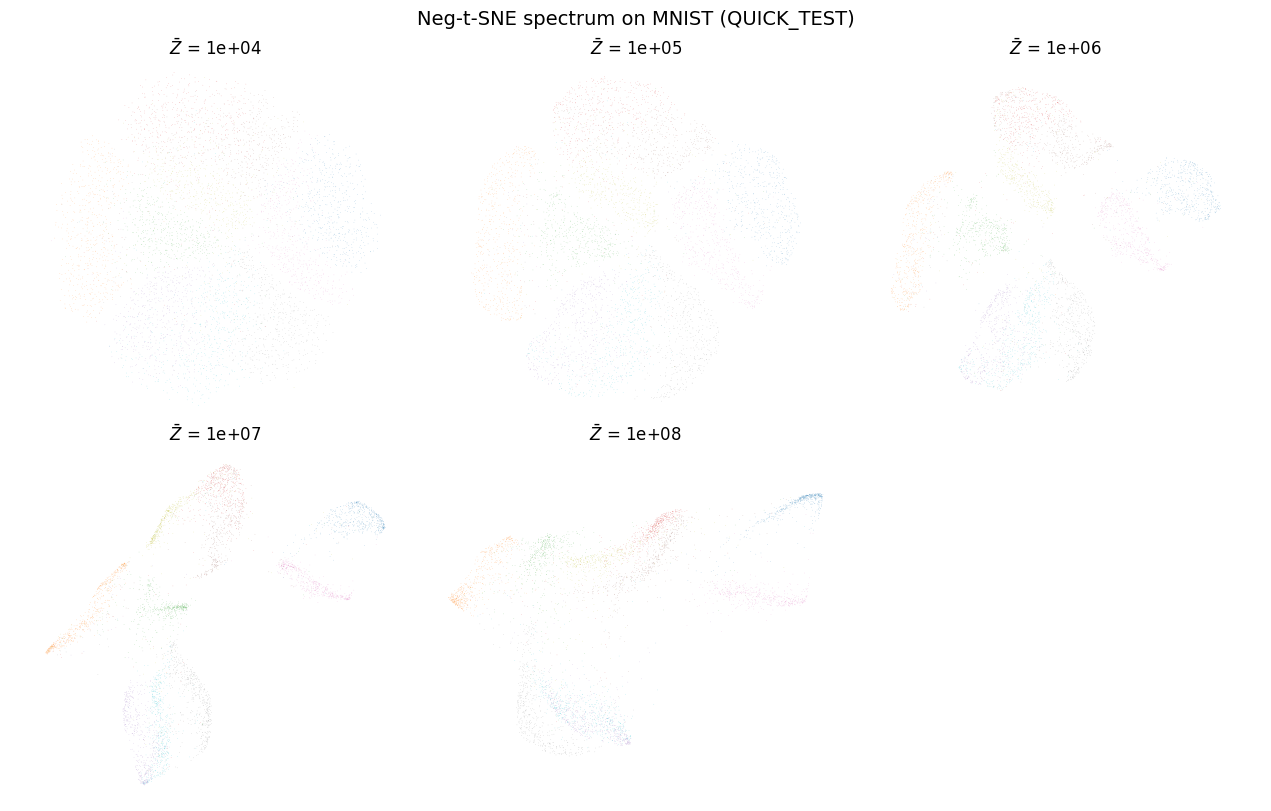

In [8]:
title = "Neg-t-SNE spectrum on MNIST"
if QUICK_TEST:
    title += " (QUICK_TEST)"
plot_embedding_spectrum(embeddings, y, Z_BARS, suptitle=title)
plt.show()

## 5. Nhận xét

- $\bar{Z}$ nhỏ: cụm digit tách rời hơn (gần t-SNE).
- $\bar{Z}$ lớn: embedding co lại, cụm gọn hơn (tiệm cận UMAP tại $\bar{Z} \approx n^2/m$).
- Spectrum giúp tránh over-interpret một embedding đơn lẻ (Damrich et al., 2023).